# `concavity_w5000` readout-mask diagnostics

Reproduces the style of `nathans_analysis.png`: for a handful of example neurons,
show the `Factorized2d` readout mask (spatial pooling weights, top row of each
seed block) next to the cumulative mass of that mask as a function of distance
from its peak (bottom row of each seed block) — a quick visual check of how
peaked/concave the masks are, and how consistent that is across seeds.

Checkpoints used: `../training/runs/concavity_w5000_seed{42,101,569}` (the three
cross-seed runs for `concavity_reg_weight=5000`, same runs as
`clustering_analysis_concavity_w5000_sanity_check_short.ipynb`). Mask
reconstruction reuses `reconstruct_session`/`compute_peak_and_r50` from
`run_diagnostics.py`.

In [1]:
import re

import matplotlib.pyplot as plt
import numpy as np
import torch

from run_diagnostics import compute_peak_and_r50, reconstruct_session

torch.set_grad_enabled(False)

torch.autograd.grad_mode.set_grad_enabled(mode=False)

In [2]:
SEEDS = [42, 101, 569]
RUN_DIR = "../training/runs/concavity_w5000_seed{seed}"
N_EXAMPLE_NEURONS = 8

In [3]:
def load_masks(seed):
    """Concatenate per-session Factorized2d masks (sorted session order) for one seed's checkpoint."""
    sd = torch.load(RUN_DIR.format(seed=seed) + "/model_weights.pth", map_location="cpu")
    sessions = sorted({m.group(1) for k in sd if (m := re.match(r"readout\.([^.]+)\.spatial_w$", k))})
    masks = [reconstruct_session(sd, s)["mask"] for s in sessions]
    return sessions, torch.cat(masks, dim=0)

In [4]:
masks_by_seed = {}
for seed in SEEDS:
    sessions, masks = load_masks(seed)
    masks_by_seed[seed] = masks

sessions, {seed: tuple(m.shape) for seed, m in masks_by_seed.items()}

/user/turishcheva/nathans_code/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")


(['21067-10-18',
  '22846-10-16',
  '23343-5-17',
  '23656-14-22',
  '23964-4-22',
  '26872-17-20',
  '27204-5-13'],
 {42: (54569, 28, 56), 101: (54569, 28, 56), 569: (54569, 28, 56)})

### Pick example neurons

Rank neurons by `r50` (radius containing 50% of the mask's mass, from
`compute_peak_and_r50`) on the first seed and take 8 evenly spaced quantiles —
from the most concentrated to the most diffuse mask — so the example panel
shows the range of mask shapes produced by this regularizer, same as in
`nathans_analysis.png`.

In [5]:
reference_seed = SEEDS[0]
_, _, r50 = compute_peak_and_r50(masks_by_seed[reference_seed])
order = torch.argsort(r50)
neuron_idxs = order[np.linspace(0, len(order) - 1, N_EXAMPLE_NEURONS).round().astype(int)].tolist()
neuron_idxs, r50[neuron_idxs]

([12082, 43150, 37399, 10457, 40609, 48706, 29834, 41031],
 tensor([1.4142, 1.4142, 2.0000, 2.0000, 2.2361, 2.2361, 2.2361, 4.0000]))

In [6]:
def mask_cum_curve(mask):
    """Sort pixels by distance from the mask's peak; return (sorted distances, cumulative mass)."""
    h, w = mask.shape
    yy, xx = torch.meshgrid(
        torch.arange(h, dtype=mask.dtype), torch.arange(w, dtype=mask.dtype), indexing="ij"
    )
    idx = mask.reshape(-1).argmax()
    py, px = (idx // w).float(), (idx % w).float()
    d = ((yy - py) ** 2 + (xx - px) ** 2).sqrt().reshape(-1)
    m = mask.reshape(-1)

    order = torch.argsort(d)
    d_sorted = d[order]
    cum = torch.cumsum(m[order], dim=0) / m.sum()
    return d_sorted.numpy(), cum.numpy()

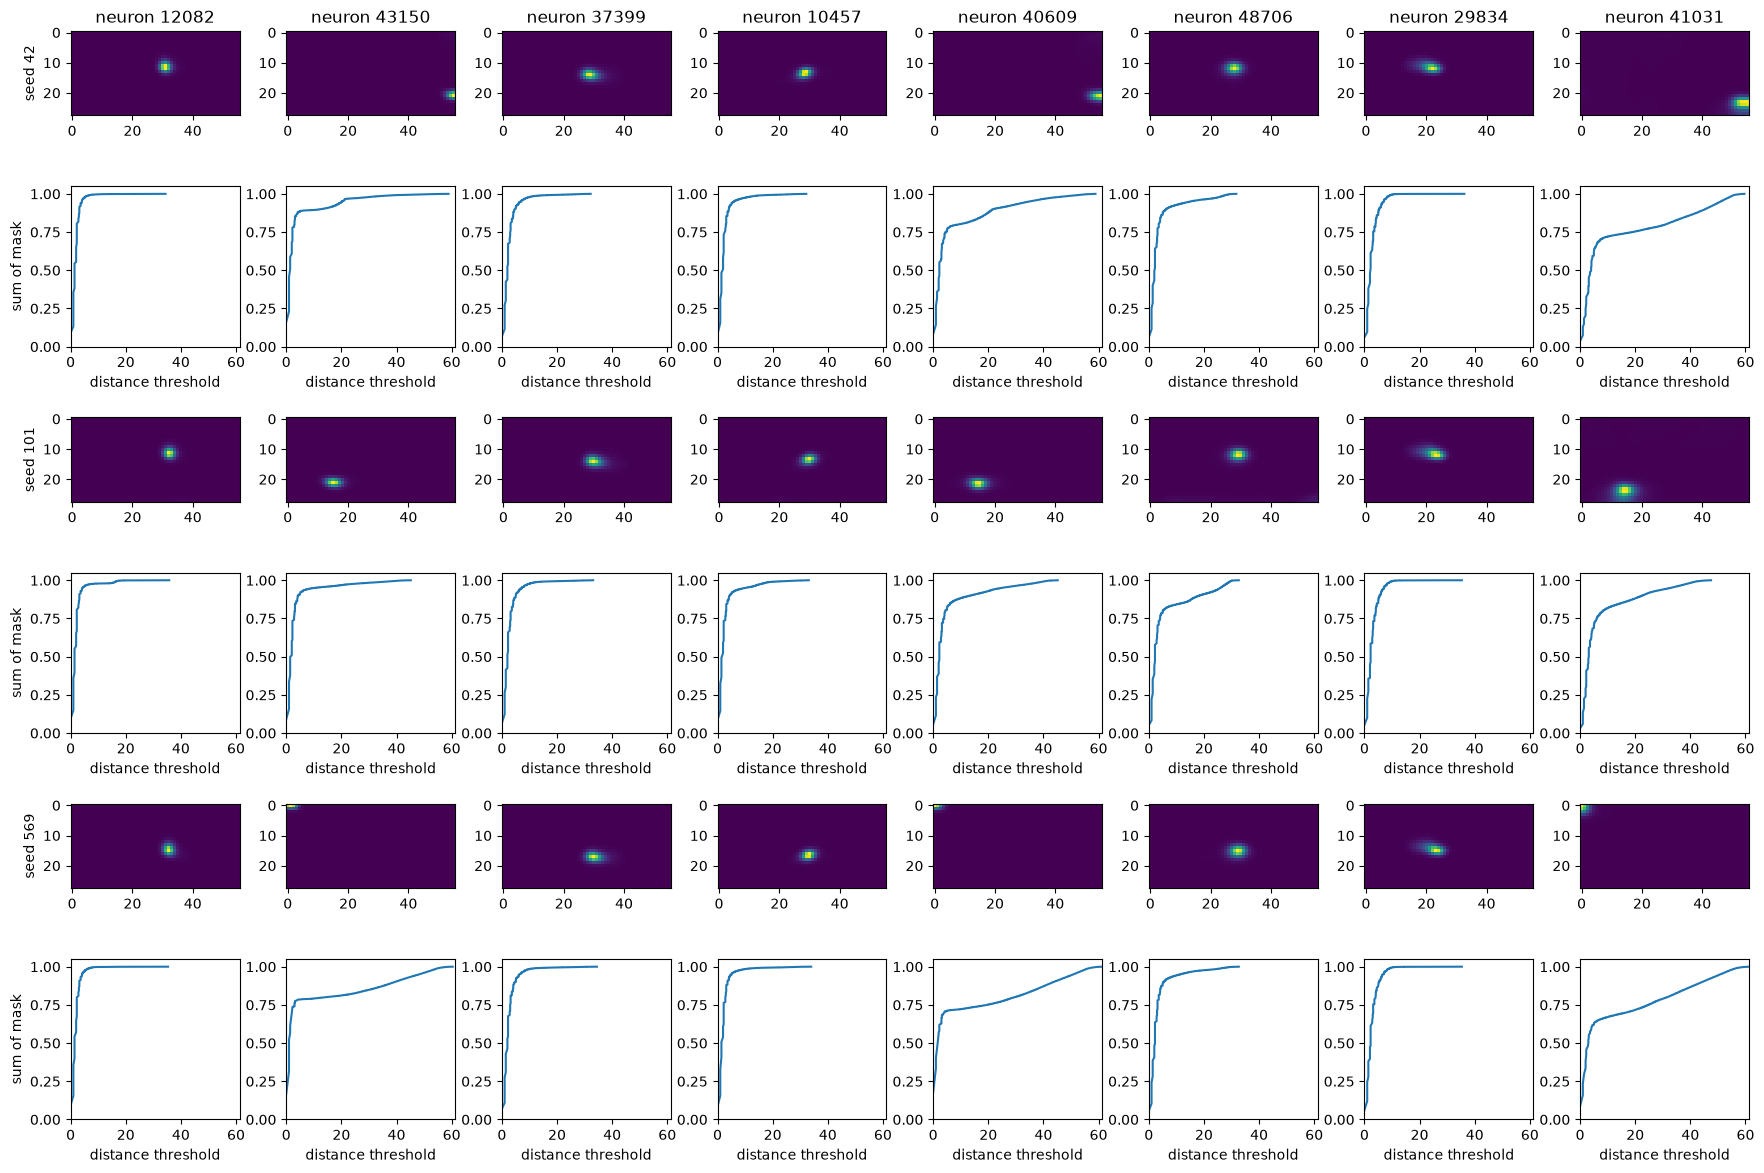

In [7]:
max_dist = max(
    mask_cum_curve(masks_by_seed[seed][n])[0].max()
    for seed in SEEDS
    for n in neuron_idxs
)

n_neurons = len(neuron_idxs)
n_seeds = len(SEEDS)
fig, axes = plt.subplots(
    n_seeds * 2, n_neurons, figsize=(2.2 * n_neurons, 2.0 * n_seeds * 2)
)

for si, seed in enumerate(SEEDS):
    masks = masks_by_seed[seed]
    row_heat, row_curve = si * 2, si * 2 + 1
    for ni, neuron in enumerate(neuron_idxs):
        mask = masks[neuron]

        ax = axes[row_heat, ni]
        ax.imshow(mask.numpy(), cmap="viridis")
        if si == 0:
            ax.set_title(f"neuron {neuron}")
        if ni == 0:
            ax.set_ylabel(f"seed {seed}")

        d_sorted, cum = mask_cum_curve(mask)
        ax2 = axes[row_curve, ni]
        ax2.plot(d_sorted, cum)
        ax2.set_xlim(0, max_dist)
        ax2.set_ylim(0, 1.05)
        ax2.set_xlabel("distance threshold")
        if ni == 0:
            ax2.set_ylabel("sum of mask")

plt.tight_layout()
plt.savefig("concavity_w5000_mask_diagnostics.png", dpi=150)
plt.show()

### Avoid 26872-17-20,

In [8]:
def load_masks(seed):
    """Concatenate per-session Factorized2d masks (sorted session order) for one seed's checkpoint."""
    sd = torch.load(RUN_DIR.format(seed=seed) + "/model_weights.pth", map_location="cpu")
    sessions = sorted({
        m.group(1)
        for k in sd
        if (m := re.match(r"readout\.([^.]+)\.spatial_w$", k))
        and "26872-17-20" not in m.group(1)
    })
    masks = [reconstruct_session(sd, s)["mask"] for s in sessions]
    return sessions, torch.cat(masks, dim=0)

In [9]:
masks_by_seed = {}
for seed in SEEDS:
    sessions, masks = load_masks(seed)
    masks_by_seed[seed] = masks

sessions, {seed: tuple(m.shape) for seed, m in masks_by_seed.items()}

(['21067-10-18',
  '22846-10-16',
  '23343-5-17',
  '23656-14-22',
  '23964-4-22',
  '27204-5-13'],
 {42: (46793, 28, 56), 101: (46793, 28, 56), 569: (46793, 28, 56)})

In [10]:
reference_seed = SEEDS[0]
_, _, r50 = compute_peak_and_r50(masks_by_seed[reference_seed])
order = torch.argsort(r50)
neuron_idxs = order[np.linspace(0, len(order) - 1, N_EXAMPLE_NEURONS).round().astype(int)].tolist()
neuron_idxs, r50[neuron_idxs]

([26694, 23860, 44280, 10537, 867, 3686, 21092, 19712],
 tensor([1.4142, 1.4142, 2.0000, 2.0000, 2.0000, 2.2361, 2.2361, 3.0000]))

In [11]:
def mask_cum_curve(mask):
    """Sort pixels by distance from the mask's peak; return (sorted distances, cumulative mass)."""
    h, w = mask.shape
    yy, xx = torch.meshgrid(
        torch.arange(h, dtype=mask.dtype), torch.arange(w, dtype=mask.dtype), indexing="ij"
    )
    idx = mask.reshape(-1).argmax()
    py, px = (idx // w).float(), (idx % w).float()
    d = ((yy - py) ** 2 + (xx - px) ** 2).sqrt().reshape(-1)
    m = mask.reshape(-1)

    order = torch.argsort(d)
    d_sorted = d[order]
    cum = torch.cumsum(m[order], dim=0) / m.sum()
    return d_sorted.numpy(), cum.numpy()

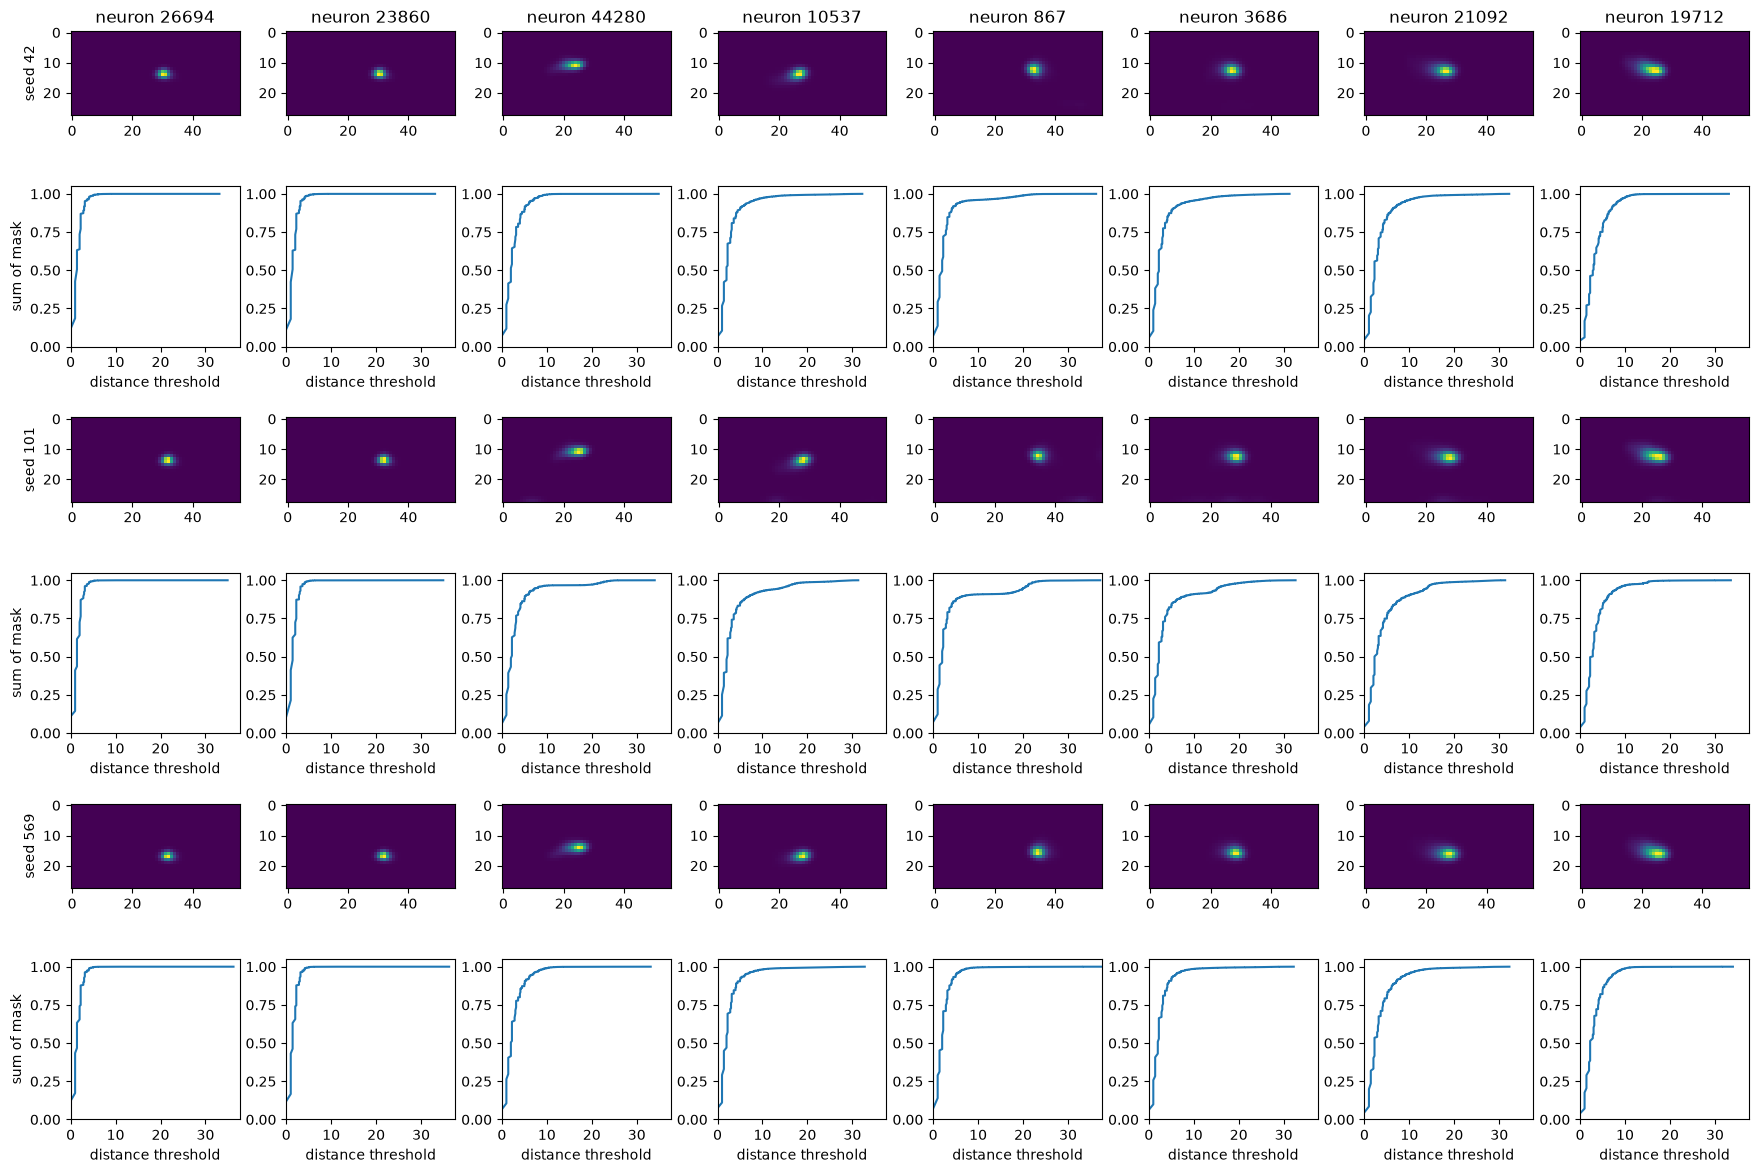

In [13]:
max_dist = max(
    mask_cum_curve(masks_by_seed[seed][n])[0].max()
    for seed in SEEDS
    for n in neuron_idxs
)

n_neurons = len(neuron_idxs)
n_seeds = len(SEEDS)
fig, axes = plt.subplots(
    n_seeds * 2, n_neurons, figsize=(2.2 * n_neurons, 2.0 * n_seeds * 2)
)

for si, seed in enumerate(SEEDS):
    masks = masks_by_seed[seed]
    row_heat, row_curve = si * 2, si * 2 + 1
    for ni, neuron in enumerate(neuron_idxs):
        mask = masks[neuron]

        ax = axes[row_heat, ni]
        ax.imshow(mask.numpy(), cmap="viridis")
        if si == 0:
            ax.set_title(f"neuron {neuron}")
        if ni == 0:
            ax.set_ylabel(f"seed {seed}")

        d_sorted, cum = mask_cum_curve(mask)
        ax2 = axes[row_curve, ni]
        ax2.plot(d_sorted, cum)
        ax2.set_xlim(0, max_dist)
        ax2.set_ylim(0, 1.05)
        ax2.set_xlabel("distance threshold")
        if ni == 0:
            ax2.set_ylabel("sum of mask")

plt.tight_layout()
plt.savefig("concavity_w5000_mask_diagnostics_6sessions.png", dpi=150)
# plt.show()